# Language Models: From N-grams to RNN, LSTM, and GRU

Welcome! In this notebook we will build up our understanding of language models from scratch:

| Part | Topic | Key idea |
|------|-------|----------|
| 1 | **N-gram Language Model** | Estimate word probabilities by counting |
| 2 | **Recurrent Neural Network (RNN)** | Process sequences with shared parameters |
| 3 | **Gradient Vanishing Problem** | Why vanilla RNNs struggle with long sequences |
| 4 | **Long Short-Term Memory (LSTM)** | Gates + cell state to fix gradient flow |
| 5 | **Gated Recurrent Unit (GRU)** | A leaner alternative to LSTM |

Each section builds on the previous one — by the end you will understand *why* each architecture was invented.

---

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import math
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

print('Libraries loaded!')
print(f'PyTorch version: {torch.__version__}')

Libraries loaded!
PyTorch version: 2.10.0+cpu


---
## Part 1 — N-gram Language Models

### What is a Language Model?

A **language model** assigns a probability to a sequence of words:

$$P(w_1, w_2, \ldots, w_T)$$

By the **chain rule of probability**, this factorises as:

$$P(w_1, \ldots, w_T) = P(w_1) \cdot P(w_2 \mid w_1) \cdot P(w_3 \mid w_1, w_2) \cdots P(w_T \mid w_1, \ldots, w_{T-1})$$

The **n-gram approximation** simplifies this by assuming each word depends only on the previous $n-1$ words (the *Markov assumption*):

- **Unigram**: $P(w_t) \approx \frac{\text{count}(w_t)}{N}$
- **Bigram**: $P(w_t \mid w_{t-1}) \approx \frac{\text{count}(w_{t-1}, w_t)}{\text{count}(w_{t-1})}$

We estimate these probabilities simply by **counting** occurrences in a corpus.

In [ ]:
# ------------------------------------------------------------------
# Corpus — Shakespeare's Hamlet soliloquy (public domain)
# ------------------------------------------------------------------
corpus_text = """to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is heir to tis a consummation
devoutly to be wished to die to sleep
to sleep perchance to dream ay there is the rub
for in that sleep of death what dreams may come
when we have shuffled off this mortal coil
must give us pause there is the respect
that makes calamity of so long life
for who would bear the whips and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the spurns
that patient merit of the unworthy takes
when he himself might his quietus make"""

sentences = [s.strip() for s in corpus_text.split('\n') if s.strip()]
all_words  = corpus_text.split()
vocab      = sorted(set(all_words))
V          = len(vocab)          # vocabulary size

print(f'Sentences : {len(sentences)}')
print(f'Words     : {len(all_words)}')
print(f'Vocabulary: {V} unique words')
print(f'\nSample sentence: "{sentences[0]}"')

Sentences : 20
Words     : 165
Vocabulary: 102 unique words

Sample sentence: "to be or not to be that is the question"


### 1-A — Unigram Model

The simplest model: every word is independent of its context.

$$P_{uni}(w) = \frac{\text{count}(w) + 1}{N + |V|}$$

The `+1` and `+|V|` terms are **Laplace (add-1) smoothing** — they ensure that unseen words get a small non-zero probability instead of zero.

In [ ]:
word_counts = Counter(all_words)
N = len(all_words)

def unigram_prob(w):
    """Laplace-smoothed unigram probability."""
    return (word_counts[w] + 1) / (N + V)

print(f'{"Word":<20} {"Count":<8} {"P(word)"}')
print('-' * 40)
for word, cnt in word_counts.most_common(10):
    print(f'{word:<20} {cnt:<8} {unigram_prob(word):.4f}')

Word                 Count    P(word)
----------------------------------------
the                  15       0.0599
to                   13       0.0524
of                   8        0.0337
and                  6        0.0262
that                 5        0.0225
sleep                5        0.0225
is                   4        0.0187
be                   3        0.0150
a                    3        0.0150
or                   2        0.0112


### 1-B — Bigram Model

Each word depends on the **one preceding word**:

$$P_{bi}(w_t \mid w_{t-1}) = \frac{\text{count}(w_{t-1},\, w_t) + 1}{\text{count}(w_{t-1}) + |V|}$$


In [ ]:
bigram_counts = defaultdict(Counter)
for i in range(len(all_words) - 1):
    bigram_counts[all_words[i]][all_words[i + 1]] += 1

def bigram_prob(w, prev):
    """Laplace-smoothed bigram probability P(w | prev)."""
    return (bigram_counts[prev][w] + 1) / (word_counts[prev] + V)

# What word tends to follow 'to'?
print('Top continuations after "to":')
print(f'{"Next word":<15} {"P(word | to)"}')
print('-' * 30)
for w, _ in bigram_counts['to'].most_common(8):
    print(f'{w:<15} {bigram_prob(w, "to"):.4f}')

Top continuations after "to":
Next word       P(word | to)
------------------------------
be              0.0348
sleep           0.0348
die             0.0261
suffer          0.0174
take            0.0174
say             0.0174
tis             0.0174
dream           0.0174


### 1-C — Sentence Probability

We use the **chain rule** to score full sentences. Because individual probabilities are very small, we work in **log-space** to avoid numerical underflow:

$$\log P_{bi}(w_1, \ldots, w_T) = \log P_{uni}(w_1) + \sum_{t=2}^{T} \log P_{bi}(w_t \mid w_{t-1})$$

Higher (= less negative) log-probability means the model thinks the sentence is more natural.

In [ ]:
def sentence_log_prob(sentence, model='bigram'):
    words = sentence.lower().split()
    if not words:
        return float('-inf')
    lp = math.log(unigram_prob(words[0]))
    if model == 'unigram':
        for w in words[1:]:
            lp += math.log(unigram_prob(w))
    else:  # bigram
        for i in range(1, len(words)):
            lp += math.log(bigram_prob(words[i], words[i - 1]))
    return lp

test_sentences = [
    'to be or not to be',          # in-corpus phrase
    'to sleep perchance to dream',  # in-corpus phrase
    'be not to or to be',           # scrambled words
    'the cat sat on the mat',       # out-of-domain
]

print(f'{"Sentence":<38} {"Unigram log-P":<16} {"Bigram log-P"}')
print('-' * 72)
for s in test_sentences:
    up = sentence_log_prob(s, 'unigram')
    bp = sentence_log_prob(s, 'bigram')
    print(f'{s:<38} {up:<16.2f} {bp:.2f}')

print('\nHigher (less negative) = sentence judged more natural by the model.')
print('Notice: bigram penalises scrambled word orders much more than unigram does!')

Sentence                               Unigram log-P    Bigram log-P
------------------------------------------------------------------------
to be or not to be                     -23.68           -21.52
to sleep perchance to dream            -19.48           -18.28
be not to or to be                     -23.68           -24.85
the cat sat on the mat                 -27.98           -26.21

Higher (less negative) = sentence judged more natural by the model.
Notice: bigram penalises scrambled word orders much more than unigram does!


### Limitations of N-gram Models

N-gram models are intuitive and fast, but they hit a wall in practice:

| Problem | Explanation |
|---------|-------------|
| **Data sparsity** | Most n-grams never appear in training data; smoothing is a hack |
| **No generalisation** | "dog" and "canine" are treated as completely unrelated words |
| **Fixed context** | Bigrams only look back 1 word; important context beyond $n-1$ steps is ignored |
| **Memory** | Storing all n-gram counts scales poorly with $n$ |

This motivates **neural language models** — and specifically **recurrent** architectures that can in principle capture context of arbitrary length.

---

## Part 2 — Recurrent Neural Networks (RNN)

### The Recurrent Idea

An RNN processes a sequence one step at a time, maintaining a **hidden state** $h_t$ that summarises everything seen so far:

$$h_t = \tanh(W_x \cdot x_t + W_h \cdot h_{t-1} + b)$$
$$\hat{y}_t = \text{softmax}(W_{out} \cdot h_t)$$

```
  x_1    x_2    x_3    x_4
   |      |      |      |
  RNN -> RNN -> RNN -> RNN
   |      |      |      |
  y_1    y_2    y_3    y_4
```

The **same** weight matrices $W_x$, $W_h$, $W_{out}$ are reused at every time step — this is the key difference from a feedforward network.

We will build a **character-level** language model: the RNN reads characters one at a time and predicts the next character. The vocabulary is just the set of unique characters in our corpus.

In [ ]:
# ------------------------------------------------------------------
# Character-level data preparation
# ------------------------------------------------------------------
chars       = sorted(set(corpus_text))
char2idx    = {c: i for i, c in enumerate(chars)}
idx2char    = {i: c for c, i in char2idx.items()}
VOCAB_CHARS = len(chars)

print(f'Character vocabulary size : {VOCAB_CHARS}')
print(f'Characters                : {repr("".join(chars))}')

# Encode the full corpus as a list of integer indices
data = [char2idx[c] for c in corpus_text]
print(f'\nCorpus length: {len(data)} characters')

# Build (input, target) pairs of fixed length using a sliding window.
# Input : characters at positions  t, t+1, ..., t+L-1
# Target: characters at positions t+1, t+2, ..., t+L   (shifted by 1)
SEQ_LEN = 30

def make_dataset(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + 1 : i + seq_len + 1])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)

X, y = make_dataset(data, SEQ_LEN)
print(f'Training examples: {X.shape}  (sequences x length)')
print(f'\nExample input : {repr(corpus_text[:SEQ_LEN])}')
print(f'Example target: {repr(corpus_text[1:SEQ_LEN+1])}')

Character vocabulary size : 25
Characters                : '\n abcdefghiklmnopqrstuvwy'

Corpus length: 839 characters
Training examples: torch.Size([809, 30])  (sequences x length)

Example input : 'to be or not to be that is the'
Example target: 'o be or not to be that is the '


### RNN Model Architecture

Our model has three components:

1. **Embedding layer** — maps each character index to a dense vector  
2. **RNN layer** — processes the sequence and updates the hidden state  
3. **Linear (output) layer** — projects the hidden state to vocabulary-size logits  

In [ ]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_dim)
        self.rnn         = nn.RNN(embed_dim, hidden_size, num_layers,
                                  batch_first=True)
        self.fc          = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        emb    = self.embedding(x)      # (B, T, embed_dim)
        out, h = self.rnn(emb, h)       # out: (B, T, H)
        logits = self.fc(out)           # (B, T, vocab_size)
        return logits, h

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)


EMBED_DIM   = 32
HIDDEN_SIZE = 128

rnn_model = CharRNN(VOCAB_CHARS, EMBED_DIM, HIDDEN_SIZE)
print(f'RNN model parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')

RNN model parameters: 24,761


In [ ]:
# ------------------------------------------------------------------
# Generic training function (works for RNN, LSTM, GRU)
# ------------------------------------------------------------------
def train_model(model, X, y, epochs=300, batch_size=64, lr=3e-3, name='Model'):
    optimizer  = optim.Adam(model.parameters(), lr=lr)
    criterion  = nn.CrossEntropyLoss()
    losses     = []
    n_batches  = len(X) // batch_size

    for epoch in range(epochs):
        perm   = torch.randperm(len(X))
        Xs, ys = X[perm], y[perm]
        epoch_loss = 0.0

        for b in range(n_batches):
            xb    = Xs[b * batch_size : (b + 1) * batch_size]
            yb    = ys[b * batch_size : (b + 1) * batch_size]
            state = model.init_hidden(len(xb))

            optimizer.zero_grad()
            logits, _ = model(xb, state)
            # logits: (B, T, V)  yb: (B, T)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)  # gradient clipping
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / n_batches
        losses.append(avg)
        if (epoch + 1) % 60 == 0:
            print(f'[{name}] Epoch {epoch+1:>3}/{epochs}  loss={avg:.4f}')

    return losses


# ------------------------------------------------------------------
# Generic text generation function (works for RNN, LSTM, GRU)
# ------------------------------------------------------------------
def generate_text(model, seed, length=150, temperature=0.8):
    model.eval()
    with torch.no_grad():
        indices = [char2idx.get(c, 0) for c in seed]
        x_seed  = torch.tensor(indices, dtype=torch.long).unsqueeze(0)
        state   = model.init_hidden(1)
        _, state = model(x_seed, state)   # prime the hidden state

        generated = list(seed)
        last_idx  = indices[-1]

        for _ in range(length):
            x_in          = torch.tensor([[last_idx]], dtype=torch.long)
            logits, state = model(x_in, state)
            probs         = torch.softmax(logits[0, 0] / temperature, dim=0)
            last_idx      = torch.multinomial(probs, 1).item()
            generated.append(idx2char[last_idx])

    return ''.join(generated)


print('train_model() and generate_text() defined.')

train_model() and generate_text() defined.


In [ ]:
# Train the RNN
rnn_losses = train_model(rnn_model, X, y, epochs=300, name='RNN')

[RNN] Epoch  60/300  loss=0.1524
[RNN] Epoch 120/300  loss=0.1428
[RNN] Epoch 180/300  loss=0.1392
[RNN] Epoch 240/300  loss=0.1385
[RNN] Epoch 300/300  loss=0.1376


In [ ]:
# Let the RNN generate text from a seed phrase
seed = 'to be or not'
print('Seed:', repr(seed))
print('=' * 60)
print(generate_text(rnn_model, seed))

Seed: 'to be or not'
to be or not of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is


The RNN can capture short-range patterns fairly well. However, training it on **longer sequences** reveals a deep problem.

---

## Part 3 — The Gradient Vanishing Problem

### Why Does Training Break Down?

Training uses **Backpropagation Through Time (BPTT)**: we unroll the RNN along the sequence and apply the chain rule to compute $\frac{\partial \mathcal{L}}{\partial h_t}$.

For a vanilla RNN with $h_t = \tanh(W_h h_{t-1} + W_x x_t)$, the gradient at time step $t$ involves a product of Jacobians:

$$\frac{\partial h_T}{\partial h_t} = \prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}} = \prod_{k=t+1}^{T} W_h^\top \cdot \text{diag}(1 - \tanh^2(\cdot))$$

The $\tanh$ derivative is in $[0, 1]$, and repeated multiplication of matrices with spectral radius $< 1$ leads to **exponential decay**:

$$\left\|\frac{\partial \mathcal{L}}{\partial h_t}\right\| \approx \rho^{T-t} \cdot \left\|\frac{\partial \mathcal{L}}{\partial h_T}\right\|, \quad \rho < 1$$

This means **the gradient signal that reaches early time steps is nearly zero** — the model cannot learn long-range dependencies.

Let's observe this empirically.

In [ ]:
def gradient_norms_rnn(seq_len, input_size=16, hidden_size=64):
    """
    Run a forward pass through an RNNCell for `seq_len` steps,
    then backpropagate from the final hidden state and measure
    the gradient norm at every time step.
    """
    cell   = nn.RNNCell(input_size, hidden_size)
    x_seq  = [torch.randn(1, input_size) for _ in range(seq_len)]
    h      = torch.zeros(1, hidden_size)
    h_list = []

    for t in range(seq_len):
        h = cell(x_seq[t], h)
        h.retain_grad()    # needed to access grad of non-leaf tensor
        h_list.append(h)

    h_list[-1].sum().backward()   # simple scalar loss from final state

    return [h.grad.norm().item() if h.grad is not None else 0.0
            for h in h_list]


def gradient_norms_lstm(seq_len, input_size=16, hidden_size=64):
    cell   = nn.LSTMCell(input_size, hidden_size)
    x_seq  = [torch.randn(1, input_size) for _ in range(seq_len)]
    h      = torch.zeros(1, hidden_size)
    c      = torch.zeros(1, hidden_size)
    h_list = []

    for t in range(seq_len):
        h, c = cell(x_seq[t], (h, c))
        h.retain_grad()
        h_list.append(h)

    h_list[-1].sum().backward()

    return [h.grad.norm().item() if h.grad is not None else 0.0
            for h in h_list]


def gradient_norms_gru(seq_len, input_size=16, hidden_size=64):
    cell   = nn.GRUCell(input_size, hidden_size)
    x_seq  = [torch.randn(1, input_size) for _ in range(seq_len)]
    h      = torch.zeros(1, hidden_size)
    h_list = []

    for t in range(seq_len):
        h = cell(x_seq[t], h)
        h.retain_grad()
        h_list.append(h)

    h_list[-1].sum().backward()

    return [h.grad.norm().item() if h.grad is not None else 0.0
            for h in h_list]


# Compute gradient norms for a long sequence
GRAD_SEQ_LEN = 60
rnn_gnorms   = gradient_norms_rnn(GRAD_SEQ_LEN)

print('Gradient norms in RNN across time steps')
print(f'  Steps  0-4  (early): {[f"{g:.4f}" for g in rnn_gnorms[:5]]}')
print(f'  Steps 55-59  (late): {[f"{g:.4f}" for g in rnn_gnorms[-5:]]}')
print(f'\nRatio early/late: {rnn_gnorms[0] / (rnn_gnorms[-1] + 1e-12):.1e}')

Gradient norms in RNN across time steps
  Steps  0-4  (early): ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']
  Steps 55-59  (late): ['0.6555', '1.2359', '2.1133', '3.9568', '8.0000']

Ratio early/late: 1.4e-16


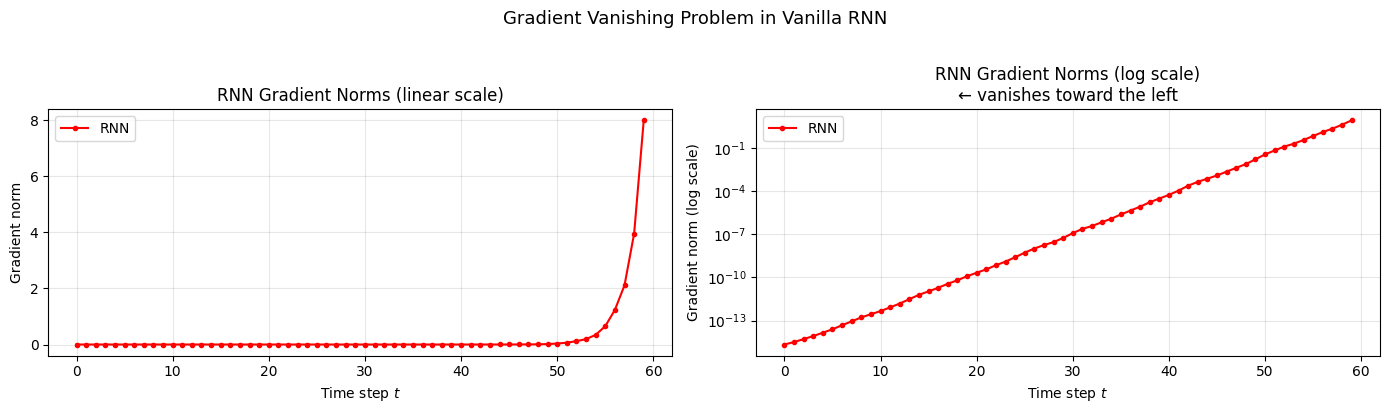

The gradient at t=0 is tiny compared to t=59.
This means the loss provides almost NO training signal to early time steps.
The RNN cannot learn that what happened 50+ steps ago matters now.


In [ ]:
# Visualise gradient vanishing in RNN
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

steps = list(range(GRAD_SEQ_LEN))

axes[0].plot(steps, rnn_gnorms, 'r-o', markersize=3, linewidth=1.5, label='RNN')
axes[0].set_xlabel('Time step $t$')
axes[0].set_ylabel('Gradient norm')
axes[0].set_title('RNN Gradient Norms (linear scale)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(steps, [g + 1e-15 for g in rnn_gnorms],
                 'r-o', markersize=3, linewidth=1.5, label='RNN')
axes[1].set_xlabel('Time step $t$')
axes[1].set_ylabel('Gradient norm (log scale)')
axes[1].set_title('RNN Gradient Norms (log scale)\n← vanishes toward the left')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Gradient Vanishing Problem in Vanilla RNN', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('The gradient at t=0 is tiny compared to t=59.')
print('This means the loss provides almost NO training signal to early time steps.')
print('The RNN cannot learn that what happened 50+ steps ago matters now.')

### Takeaway

- Gradients decay **exponentially** with the distance from the loss.  
- Parameters at early time steps receive almost **no useful update signal**.  
- The RNN effectively has a **short-term memory** — it forgets the distant past during training.  

This is the precise problem that LSTM was designed to solve.

---

## Part 4 — Long Short-Term Memory (LSTM)

### The Key Insight: A Separate Memory Highway

LSTM (Hochreiter & Schmidhuber, 1997) introduces a **cell state** $c_t$ that runs alongside the hidden state $h_t$. The cell state acts as a protected memory channel: information can flow through it across many time steps with minimal transformation, allowing gradients to survive long distances.

Three **gates** (each a sigmoid, output in $[0,1]$) control information flow:

```
  x_t, h_{t-1}
       |
       ├──► Forget gate   f_t = σ(W_f·[h_{t-1}, x_t] + b_f)
       |       ↓  how much of old cell state to keep
       |    c_{t-1} × f_t
       |                 \  
       ├──► Input gate    i_t = σ(W_i·[h_{t-1}, x_t] + b_i)
       ├──► Candidate     g_t = tanh(W_g·[h_{t-1}, x_t] + b_g)
       |       ↓  how much new info to write
       |    + i_t × g_t
       |                 /
       |    c_t  ←───────   (cell state update — the "highway")
       |       ↓
       └──► Output gate   o_t = σ(W_o·[h_{t-1}, x_t] + b_o)
               ↓
            h_t = o_t × tanh(c_t)
```

The update equation for $c_t$ is:
$$c_t = f_t \odot c_{t-1} + i_t \odot g_t$$

When $f_t \approx 1$ and $i_t \approx 0$, the cell state is **copied** without any squashing — this is the "constant error carousel" that prevents gradient vanishing.

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_dim)
        self.lstm        = nn.LSTM(embed_dim, hidden_size, num_layers,
                                   batch_first=True)
        self.fc          = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        emb         = self.embedding(x)
        out, state  = self.lstm(emb, state)   # state = (h, c)
        logits      = self.fc(out)
        return logits, state

    def init_hidden(self, batch_size):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        return (h0, c0)   # LSTM state is a (h, c) tuple


lstm_model = CharLSTM(VOCAB_CHARS, EMBED_DIM, HIDDEN_SIZE)
print(f'LSTM model parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')
print('(~4x more than RNN because of the 4 gate matrices)')

LSTM model parameters: 86,969
(~4x more than RNN because of the 4 gate matrices)


In [ ]:
# Train LSTM — same train_model() function works because init_hidden() handles the tuple
lstm_losses = train_model(lstm_model, X, y, epochs=300, name='LSTM')

[LSTM] Epoch  60/300  loss=0.1437
[LSTM] Epoch 120/300  loss=0.1372
[LSTM] Epoch 180/300  loss=0.1358
[LSTM] Epoch 240/300  loss=0.1348
[LSTM] Epoch 300/300  loss=0.1338


In [ ]:
print('Generated text (LSTM):')
print('=' * 60)
print(generate_text(lstm_model, 'to be or not'))

Generated text (LSTM):
to be or not or be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of trou


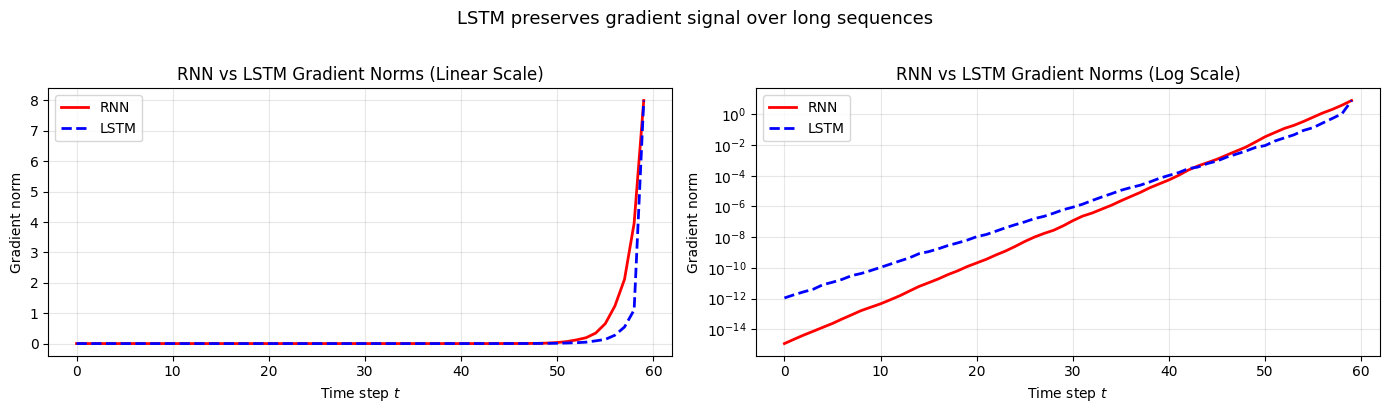

LSTM early/late ratio: 1.4e-13
RNN  early/late ratio: 1.4e-16

The LSTM ratio is much closer to 1 — gradients survive much longer!


In [ ]:
# Now compare gradient norms: RNN vs LSTM
lstm_gnorms = gradient_norms_lstm(GRAD_SEQ_LEN)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, yscale, title in zip(
        axes,
        ['linear', 'log'],
        ['Linear Scale', 'Log Scale']):
    ax.plot(steps, rnn_gnorms,  'r-',  linewidth=2, label='RNN')
    ax.plot(steps, lstm_gnorms, 'b--', linewidth=2, label='LSTM')
    ax.set_yscale(yscale)
    ax.set_xlabel('Time step $t$')
    ax.set_ylabel('Gradient norm')
    ax.set_title(f'RNN vs LSTM Gradient Norms ({title})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM preserves gradient signal over long sequences', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'LSTM early/late ratio: {lstm_gnorms[0] / (lstm_gnorms[-1] + 1e-12):.1e}')
print(f'RNN  early/late ratio: {rnn_gnorms[0]  / (rnn_gnorms[-1]  + 1e-12):.1e}')
print('\nThe LSTM ratio is much closer to 1 — gradients survive much longer!')

### Why Does LSTM Help?

The gradient of the loss with respect to the **cell state** $c_t$ propagates as:

$$\frac{\partial \mathcal{L}}{\partial c_t} = \frac{\partial \mathcal{L}}{\partial c_{t+1}} \cdot f_{t+1}$$

When the forget gate $f_{t+1} \approx 1$, the gradient flows back **almost unchanged** — there is no repeated multiplication by a small Jacobian. This is the "constant error carousel" mechanism that Hochreiter & Schmidhuber described.

---

## Part 5 — Gated Recurrent Unit (GRU)

### A Leaner Alternative

GRU (Cho et al., 2014) achieves a similar effect to LSTM but with **fewer parameters** by merging the forget and input gates into a single **update gate**:

```
  x_t, h_{t-1}
       |
       ├──► Reset gate   r_t = σ(W_r·[h_{t-1}, x_t])
       |       controls how much past state to use when computing new candidate
       |
       ├──► Update gate  z_t = σ(W_z·[h_{t-1}, x_t])
       |       how much to update vs. keep the old state
       |
       └──► Candidate    n_t = tanh(W_n·[r_t⊙h_{t-1}, x_t])

  h_t = (1 - z_t) ⊙ h_{t-1}  +  z_t ⊙ n_t
         ^^^^^^^^^^^^^^^^^^^^^     ^^^^^^^^^^^^
           keep old state           add new info
```

When $z_t \approx 0$, the hidden state is passed through **unchanged** (like the LSTM cell state with $f \approx 1$), giving similar gradient-highway properties with fewer gates.

In [ ]:
class CharGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.embedding   = nn.Embedding(vocab_size, embed_dim)
        self.gru         = nn.GRU(embed_dim, hidden_size, num_layers,
                                  batch_first=True)
        self.fc          = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        emb    = self.embedding(x)
        out, h = self.gru(emb, h)
        logits = self.fc(out)
        return logits, h

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)


gru_model = CharGRU(VOCAB_CHARS, EMBED_DIM, HIDDEN_SIZE)
print(f'GRU  model parameters: {sum(p.numel() for p in gru_model.parameters()):,}')
print(f'LSTM model parameters: {sum(p.numel() for p in lstm_model.parameters()):,}')
print(f'RNN  model parameters: {sum(p.numel() for p in rnn_model.parameters()):,}')
print('\nGRU has ~3/4 the parameters of LSTM (3 gate matrices vs 4).')

GRU  model parameters: 66,233
LSTM model parameters: 86,969
RNN  model parameters: 24,761

GRU has ~3/4 the parameters of LSTM (3 gate matrices vs 4).


In [ ]:
gru_losses = train_model(gru_model, X, y, epochs=300, name='GRU')

[GRU] Epoch  60/300  loss=0.1407
[GRU] Epoch 120/300  loss=0.1358
[GRU] Epoch 180/300  loss=0.1344
[GRU] Epoch 240/300  loss=0.1337
[GRU] Epoch 300/300  loss=0.1333


In [ ]:
print('Generated text (GRU):')
print('=' * 60)
print(generate_text(gru_model, 'to be or not'))

Generated text (GRU):
to be or not the whips and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the 


In [ ]:
gru_gnorms = gradient_norms_gru(GRAD_SEQ_LEN)

---

## Part 6 — Full Comparison

Let's look at training loss and gradient flow side by side for all three architectures.

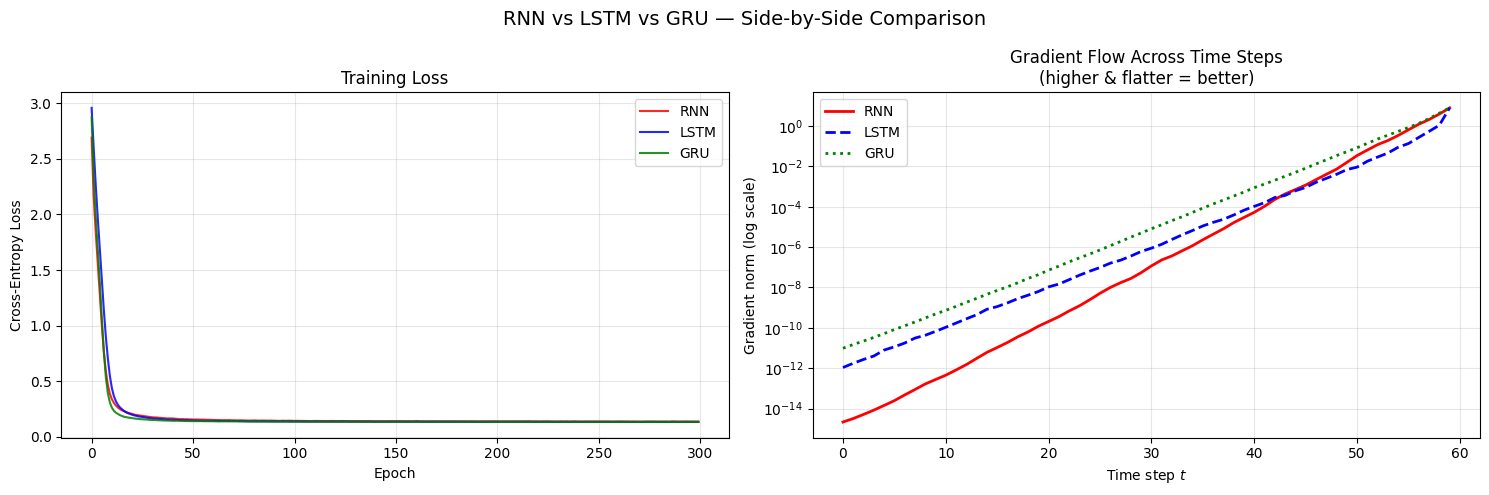

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Training loss ──────────────────────────────────────────
ax = axes[0]
ax.plot(rnn_losses,  'r-',  linewidth=1.5, alpha=0.85, label='RNN')
ax.plot(lstm_losses, 'b-',  linewidth=1.5, alpha=0.85, label='LSTM')
ax.plot(gru_losses,  'g-',  linewidth=1.5, alpha=0.85, label='GRU')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Right: Gradient flow ─────────────────────────────────────────
ax = axes[1]
ax.semilogy(steps, [g + 1e-15 for g in rnn_gnorms],
            'r-',  linewidth=2, label='RNN')
ax.semilogy(steps, [g + 1e-15 for g in lstm_gnorms],
            'b--', linewidth=2, label='LSTM')
ax.semilogy(steps, [g + 1e-15 for g in gru_gnorms],
            'g:',  linewidth=2, label='GRU')
ax.set_xlabel('Time step $t$')
ax.set_ylabel('Gradient norm (log scale)')
ax.set_title('Gradient Flow Across Time Steps\n(higher & flatter = better)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('RNN vs LSTM vs GRU — Side-by-Side Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── Summary table ────────────────────────────────────────────────
print(f'{"":<6} {"Params":>10}  {"Final Loss":>12}  {"Grad ratio (early/late)":>26}')
print('-' * 60)

for name, model, losses, gnorms in [
        ('RNN',  rnn_model,  rnn_losses,  rnn_gnorms),
        ('LSTM', lstm_model, lstm_losses, lstm_gnorms),
        ('GRU',  gru_model,  gru_losses,  gru_gnorms)]:
    params = sum(p.numel() for p in model.parameters())
    ratio  = gnorms[0] / (gnorms[-1] + 1e-12)
    print(f'{name:<6} {params:>10,}  {losses[-1]:>12.4f}  {ratio:>26.2e}')

print('\nGrad ratio: how much smaller the gradient is at step 0 vs step 59.')
print('Values near 1e0 = good; values near 1e-10 = severe vanishing.')

           Params    Final Loss     Grad ratio (early/late)
------------------------------------------------------------
RNN        24,761        0.1376                    1.45e-16
LSTM       86,969        0.1338                    1.36e-13
GRU        66,233        0.1333                    1.22e-12

Grad ratio: how much smaller the gradient is at step 0 vs step 59.
Values near 1e0 = good; values near 1e-10 = severe vanishing.


---

## Summary

### What We Built

| Model | Mechanism | Long-range memory | Parameters |
|-------|-----------|-------------------|------------|
| N-gram | Count-based statistics | ✗ fixed context | N/A |
| RNN | Single hidden state, tanh | ✗ gradients vanish | Lowest |
| LSTM | Cell state + 3 gates | ✓ constant error carousel | ~4× RNN |
| GRU | Update/reset gates | ✓ similar to LSTM | ~3× RNN |

### Key Takeaways

1. **N-gram models** are probabilistic and interpretable but suffer from data sparsity and cannot generalise beyond seen n-grams.

2. **RNNs** parameterise the language model with shared weights across time steps, enabling generalisation — but vanilla RNNs fail to learn long-range dependencies because gradients vanish exponentially during backpropagation through time.

3. **LSTM** solves this with a separate **cell state** that forms a gradient highway. The forget gate can be close to 1, allowing the error signal to flow back in time without attenuation.

4. **GRU** achieves similar gradient flow with fewer parameters by merging the forget and input gates into a single update gate.

### What Comes Next?

Both LSTM and GRU are still sequential — they process one token at a time, which limits parallelism. The modern successor is the **Transformer** (Vaswani et al., 2017), which replaces recurrence entirely with **self-attention** and processes the whole sequence at once. LSTM/GRU remain relevant for streaming and low-latency settings, but Transformers now dominate large-scale language modelling.

---
## Practice — Design Your Own Language Model

### Your Challenge

Build a character-level language model that achieves the **lowest perplexity** on a held-out test set.

**Perplexity** is the standard metric for language models:
$$\text{PPL} = \exp\!\left(\frac{1}{T}\sum_{t=1}^{T} -\log P(w_t \mid w_{<t})\right) = \exp(\text{cross-entropy loss})$$

Lower is better. A model guessing randomly scores $\approx |V|$. A perfect model scores 1.

### Design Decisions You Must Make

| Hyperparameter | What it controls | Suggested range |
|----------------|------------------|-----------------|
| `cell_type` | RNN / LSTM / GRU | one of the three |
| `embed_dim` | character embedding size | 16 – 128 |
| `hidden_size` | recurrent layer width | 64 – 512 |
| `num_layers` | depth (stacked layers) | 1 – 3 |
| `dropout` | regularisation between layers | 0.0 – 0.5 |
| `seq_len` | context window (characters) | 20 – 80 |
| `lr` | learning rate | 1e-4 – 1e-2 |
| `epochs` | training budget | 200 – 600 |

### Hints
- Start simple — get a baseline working first, then tune **one thing at a time**.
- Adding a second layer (`num_layers=2`) often helps; beyond 2, `dropout` becomes important.
- A longer `seq_len` gives more context but requires more memory and training time.
- If the training loss is still dropping at the end, increase `epochs` or `lr`.
- If the loss fluctuates wildly, reduce `lr` or increase `batch_size`.

In [23]:
# ------------------------------------------------------------------
# Larger corpus — train / test split
# ------------------------------------------------------------------
extended_corpus = """to be or not to be that is the question
whether tis nobler in the mind to suffer
the slings and arrows of outrageous fortune
or to take arms against a sea of troubles
and by opposing end them to die to sleep
no more and by a sleep to say we end
the heartache and the thousand natural shocks
that flesh is heir to tis a consummation
devoutly to be wished to die to sleep
to sleep perchance to dream ay there is the rub
for in that sleep of death what dreams may come
when we have shuffled off this mortal coil
must give us pause there is the respect
that makes calamity of so long life
for who would bear the whips and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the spurns
that patient merit of the unworthy takes
when he himself might his quietus make
with a bare bodkin who would fardels bear
to grunt and sweat under a weary life
but that the dread of something after death
the undiscovered country from whose bourn
no traveller returns puzzles the will
and makes us rather bear those ills we have
than fly to others that we know not of
thus conscience does make cowards of us all
and thus the native hue of resolution
is sicklied over with the pale cast of thought
and enterprises of great pitch and moment
with this regard their currents turn awry
and lose the name of action soft you now
the fair ophelia nymph in thy orisons
be all my sins remembered"""

all_chars2  = sorted(set(extended_corpus))
c2i2        = {c: i for i, c in enumerate(all_chars2)}
i2c2        = {i: c for c, i in c2i2.items()}
VOCAB2      = len(all_chars2)

encoded2    = [c2i2[c] for c in extended_corpus]
split       = int(len(encoded2) * 0.8)
train_data2 = encoded2[:split]
test_data2  = encoded2[split:]

print(f'Vocabulary size : {VOCAB2} characters')
print(f'Train chars     : {len(train_data2)}')
print(f'Test  chars     : {len(test_data2)}')

Vocabulary size : 26 characters
Train chars     : 1155
Test  chars     : 289


In [24]:
# ------------------------------------------------------------------
# Perplexity evaluation
# ------------------------------------------------------------------
def make_ds2(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + 1 : i + seq_len + 1])
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.long)


def compute_perplexity(model, data, seq_len, batch_size=64):
    """Perplexity = exp(mean cross-entropy) — lower is better."""
    model.eval()
    Xd, yd    = make_ds2(data, seq_len)
    criterion = nn.CrossEntropyLoss()
    total, nb = 0.0, len(Xd) // batch_size

    if nb == 0:
        return float('inf')

    with torch.no_grad():
        for b in range(nb):
            xb    = Xd[b * batch_size : (b + 1) * batch_size]
            yb    = yd[b * batch_size : (b + 1) * batch_size]
            state = model.init_hidden(len(xb))
            logits, _ = model(xb, state)
            total += criterion(logits.reshape(-1, logits.size(-1)),
                               yb.reshape(-1)).item()

    return math.exp(total / nb)


print('compute_perplexity() defined.')
print('Usage: compute_perplexity(my_model, test_data2, seq_len=MY_SEQ_LEN)')

compute_perplexity() defined.
Usage: compute_perplexity(my_model, test_data2, seq_len=MY_SEQ_LEN)


In [25]:
# ------------------------------------------------------------------
# Baseline scores from the models trained earlier
# ------------------------------------------------------------------
BASELINE_SEQ = 30

print(f'{"Model":<25}  {"Test Perplexity":>16}')
print('-' * 44)
for label, m in [('RNN  (baseline)', rnn_model),
                  ('LSTM (baseline)', lstm_model),
                  ('GRU  (baseline)', gru_model)]:
    ppl = compute_perplexity(m, test_data2, BASELINE_SEQ)
    print(f'{label:<25}  {ppl:>16.2f}')

print('\nYour goal: beat the best baseline!')

Model                       Test Perplexity
--------------------------------------------
RNN  (baseline)                      553.73
LSTM (baseline)                      274.94
GRU  (baseline)                      273.76

Your goal: beat the best baseline!


In [26]:
# ==================================================================
#  TODO — Complete the MyLanguageModel class
# ==================================================================
class MyLanguageModel(nn.Module):
    """
    Fill in the three TODO sections.
    The interface must stay the same:
      forward(x, state)  ->  (logits, new_state)
      init_hidden(batch_size)  ->  initial state
    """

    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout=0.0, cell_type='RNN'):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.cell_type   = cell_type.upper() # Store cell type

        # ── TODO 1: Define your layers ──────────────────────────────
        # Required:
        #   self.embedding  — nn.Embedding(vocab_size, embed_dim)
        #   self.recurrent  — nn.RNN / nn.LSTM / nn.GRU
        #   self.fc         — nn.Linear(hidden_size, vocab_size)
        # Optional: nn.Dropout, nn.LayerNorm, ...
        #
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Dynamically choose recurrent layer based on cell_type
        if self.cell_type == 'LSTM':
            self.recurrent = nn.LSTM(embed_dim, hidden_size, num_layers,
                                     dropout=dropout if num_layers > 1 else 0.0,
                                     batch_first=True)
        elif self.cell_type == 'GRU':
            self.recurrent = nn.GRU(embed_dim, hidden_size, num_layers,
                                    dropout=dropout if num_layers > 1 else 0.0,
                                    batch_first=True)
        else: # Default to RNN
            self.recurrent = nn.RNN(embed_dim, hidden_size, num_layers,
                                    dropout=dropout if num_layers > 1 else 0.0,
                                    batch_first=True)
        self.fc        = nn.Linear(hidden_size, vocab_size)
        # ────────────────────────────────────────────────────────────

    def forward(self, x, state=None):
        # ── TODO 2: Forward pass ────────────────────────────────────
        # 1. Embed x  ->  (B, T, embed_dim)
        # 2. Run recurrent layer  ->  out (B, T, H), new_state
        # 3. Project to logits  ->  (B, T, vocab_size)
        #
        emb            = self.embedding(x)
        out, new_state = self.recurrent(emb, state)
        logits         = self.fc(out)
        return logits, new_state
        # ────────────────────────────────────────────────────────────

    def init_hidden(self, batch_size):
        # ── TODO 3: Return the correct initial state ─────────────────
        # RNN / GRU : zeros tensor  (num_layers, batch_size, hidden_size)
        # LSTM      : tuple (h0, c0), each the same shape as above
        #
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
        if self.cell_type == 'LSTM':
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size)
            return (h0, c0)
        return h0
        # ────────────────────────────────────────────────────────────


print('MyLanguageModel defined — edit the TODO sections above!')

MyLanguageModel defined — edit the TODO sections above!


In [27]:
# ==================================================================
#  TODO — Set your hyperparameters here
# ==================================================================

MY_SEQ_LEN   = 30      # context window (characters)
MY_EMBED_DIM = 32      # embedding dimension
MY_HIDDEN    = 128     # hidden state size
MY_LAYERS    = 1       # number of stacked recurrent layers
MY_DROPOUT   = 0.0     # dropout (active only when MY_LAYERS > 1)
MY_LR        = 3e-3    # learning rate
MY_EPOCHS    = 150     # training epochs
MY_BATCH     = 64      # batch size

# Build train dataset with your chosen sequence length
X_my, y_my = make_ds2(train_data2, MY_SEQ_LEN)
print(f'Training sequences : {X_my.shape}')

my_model = MyLanguageModel(
    vocab_size  = VOCAB2,
    embed_dim   = MY_EMBED_DIM,
    hidden_size = MY_HIDDEN,
    num_layers  = MY_LAYERS,
    dropout     = MY_DROPOUT,
)

n_params = sum(p.numel() for p in my_model.parameters())
print(f'Model parameters   : {n_params:,}')

Training sequences : torch.Size([1125, 30])
Model parameters   : 24,922


In [28]:
# Train your model (reuses the generic train_model() from Part 2)
my_losses = train_model(
    my_model, X_my, y_my,
    epochs=MY_EPOCHS, batch_size=MY_BATCH,
    lr=MY_LR, name='MyModel'
)

[MyModel] Epoch  60/300  loss=0.1666
[MyModel] Epoch 120/300  loss=0.1567
[MyModel] Epoch 180/300  loss=0.1531
[MyModel] Epoch 240/300  loss=0.1515
[MyModel] Epoch 300/300  loss=0.1502


Model                       Test Perplexity
--------------------------------------------
RNN  (baseline)                      553.73
LSTM (baseline)                      274.94
GRU  (baseline)                      273.76
My Model ◀...............            325.17


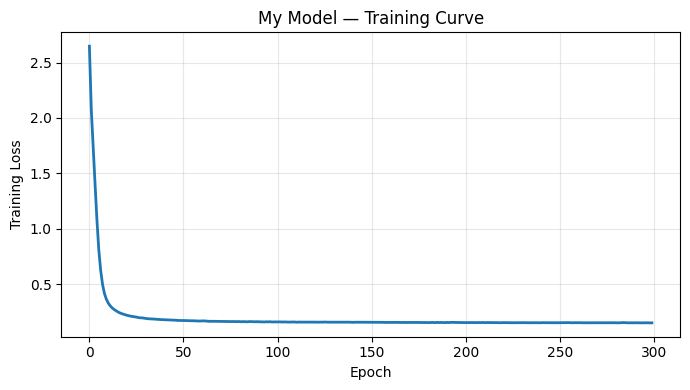


Generated text (My Model):
to be or not and scorns of time
the oppressors wrong the proud mans contumely
the pangs of despised love the laws delay
the insolence of office and the spurns
tha


In [29]:
# ------------------------------------------------------------------
# Evaluate and compare against baselines
# ------------------------------------------------------------------
my_ppl = compute_perplexity(my_model, test_data2, MY_SEQ_LEN)

print(f'{"Model":<25}  {"Test Perplexity":>16}')
print('-' * 44)
for label, m in [('RNN  (baseline)', rnn_model),
                  ('LSTM (baseline)', lstm_model),
                  ('GRU  (baseline)', gru_model)]:
    print(f'{label:<25}  {compute_perplexity(m, test_data2, BASELINE_SEQ):>16.2f}')
print(f'{"My Model ◀":.<25}  {my_ppl:>16.2f}')

# Training curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(my_losses, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('My Model — Training Curve')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sample generation
print('\nGenerated text (My Model):')
print('=' * 60)

def generate_my(model, seed, length=150, temperature=0.8):
    model.eval()
    with torch.no_grad():
        indices = [c2i2.get(c, 0) for c in seed]
        x_seed  = torch.tensor(indices, dtype=torch.long).unsqueeze(0)
        state   = model.init_hidden(1)
        _, state = model(x_seed, state)
        generated = list(seed)
        last_idx  = indices[-1]
        for _ in range(length):
            x_in          = torch.tensor([[last_idx]], dtype=torch.long)
            logits, state = model(x_in, state)
            probs         = torch.softmax(logits[0, 0] / temperature, dim=0)
            last_idx      = torch.multinomial(probs, 1).item()
            generated.append(i2c2[last_idx])
    return ''.join(generated)

print(generate_my(my_model, 'to be or not'))